In [11]:
from scipy.integrate import quad
from math import inf, exp
from scipy.stats import f
import scipy.stats as stats
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

In [12]:
def gamma(a):
    return quad(lambda x: x ** (a - 1) * exp(-x), 0, inf)[0]

def p(n, x):
    return (1/2) ** (n/2) / gamma(n/2) * x ** (n/2 - 1) * exp(-x/2)

def X_2(N, a, b):
    return quad(lambda x: p(N, x), a, b)[0]

def F(n, m, a, b):
    return quad(f.pdf, a, b, args=(n, m))[0]

In [13]:
print(F(999, 138, 1.202, inf))

0.08592982700402074


Т13

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


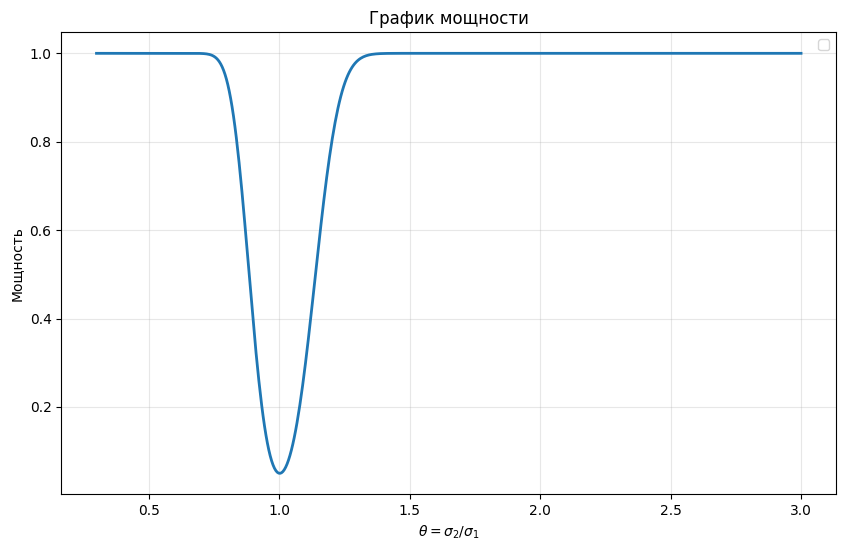

In [14]:
def s2(sig, k):
    return k / (k - 1) * sig**2

alp = 0.05

se_l = 5.722
se_w = 4.612
n1, n2 = 139, 1000

df1 = n1 - 1
df2 = n2 - 1
F_low = stats.f.ppf(alp / 2, df1, df2)
F_up = stats.f.ppf(1 - alp / 2, df1, df2)

theta = np.linspace(0.3, 3, 500)

def power_func(theta_val, df1, df2, F_low, F_up):
    # lambda = sigma1^2 / sigma2^2 = 1 / theta_val^2
    lam = 1 / (theta_val**2)
    p_left = stats.f.cdf(F_low / lam, df1, df2)
    p_right = 1 - stats.f.cdf(F_up / lam, df1, df2)
    return p_left + p_right

power_vals = [power_func(t, df1, df2, F_low, F_up) for t in theta]

plt.figure(figsize=(10, 6))
plt.plot(theta, power_vals, linewidth=2)
plt.xlabel(r'$\theta = \sigma_2 / \sigma_1$')
plt.ylabel('Мощность')
plt.title('График мощности')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Т14

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


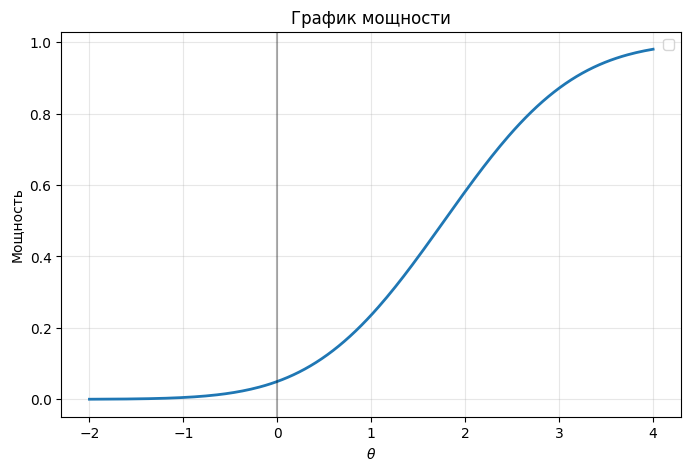

In [15]:
sigma_D = np.sqrt(2/3 + 1/2)
z_alpha = norm.ppf(0.95)

delta = np.linspace(-2, 4, 200)
power = 1 - norm.cdf(z_alpha - delta / sigma_D)

plt.figure(figsize=(8, 5))
plt.plot(delta, power, linewidth=2)
plt.axvline(0, color='k', linestyle='-', alpha=0.3)
plt.xlabel(r'$\theta$')
plt.ylabel('Мощность')
plt.title('График мощности')
plt.grid(alpha=0.3)
plt.legend()
plt.show()